# STEP 0 — Download & Explore Epidemic Forecasting Datasets

**Goal:** download, clean, inspect, and visually compare three influenza datasets.
**No models, no feature engineering, no future-filtering** — data understanding only.

Datasets:
1. **FluSight Ground Truth** — weekly incident confirmed-flu hospital admissions (the forecasting target).
2. **NHSN Hospital Respiratory Data (HRD)** — CDC, weekly confirmed-flu admissions by jurisdiction.
3. **ILINet** — Influenza-Like Illness surveillance via the Delphi Epidata `fluview` API.

> Note: the original spec asked for `truth-Incident Hospitalizations.csv`. That file no longer
> exists in the FluSight hub; the current ground-truth file is `target-hospital-admissions.csv`.
> We download that and still save it locally as `data/raw/flusight_truth.csv`.

## Cell 1 — Setup, folders & helpers

In [1]:
import os, io, time
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# Resolve project root whether the notebook runs from notebooks/ or the repo root
CWD = os.getcwd()
ROOT = os.path.dirname(CWD) if os.path.basename(CWD) == "notebooks" else CWD
RAW = os.path.join(ROOT, "data", "raw")
PROC = os.path.join(ROOT, "data", "processed")
FIGS = os.path.join(PROC, "figures")
for d in (RAW, PROC, FIGS, os.path.join(ROOT, "notebooks")):
    os.makedirs(d, exist_ok=True)
print("Project root:", ROOT)


def download(url, dest, params=None, timeout=120):
    """GET `url`, save raw bytes to `dest`, return the requests.Response."""
    r = requests.get(url, params=params, timeout=timeout)
    print(f"GET {r.url}\n  -> HTTP {r.status_code}, {len(r.content):,} bytes")
    r.raise_for_status()
    with open(dest, "wb") as f:
        f.write(r.content)
    print(f"  -> saved {dest}")
    return r


def epiweek_to_date(epiweek):
    """MMWR epiweek (YYYYWW int) -> Sunday (start) of that week as a Timestamp."""
    epiweek = int(epiweek)
    year, week = divmod(epiweek, 100)
    # MMWR week 1 contains Jan 4th; week starts on Sunday.
    jan4 = pd.Timestamp(year=year, month=1, day=4)
    week1_sun = jan4 - pd.Timedelta(days=(jan4.weekday() + 1) % 7)  # Sunday on/before Jan 4
    return week1_sun + pd.Timedelta(weeks=week - 1)


# Cross-dataset location crosswalk (national + two example states).
# Each dataset codes locations differently, so we keep all three keys.
CROSSWALK = pd.DataFrame([
    {"label": "US National", "flusight": "US", "nhsn": "USA", "ilinet": "nat"},
    {"label": "California",  "flusight": "06", "nhsn": "CA",  "ilinet": "ca"},
    {"label": "New York",    "flusight": "36", "nhsn": "NY",  "ilinet": "ny"},
])
CROSSWALK

Project root: C:\Users\UseR\Downloads\Epidemic Forecasting


,label,flusight,nhsn,ilinet
0,US National,US,USA,nat
1,California,06,CA,ca
2,New York,36,NY,ny


## Cell 2 — Download FluSight ground truth (the target)

In [2]:
FLUSIGHT_URL = ("https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/"
                "main/target-data/target-hospital-admissions.csv")
flusight_path = os.path.join(RAW, "flusight_truth.csv")

download(FLUSIGHT_URL, flusight_path)
flusight_raw = pd.read_csv(flusight_path)
print("\nRaw columns:", list(flusight_raw.columns))
flusight_raw.head()

GET https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/main/target-data/target-hospital-admissions.csv
  -> HTTP 200, 558,875 bytes
  -> saved C:\Users\UseR\Downloads\Epidemic Forecasting\data\raw\flusight_truth.csv

Raw columns: ['date', 'location', 'location_name', 'value', 'weekly_rate']


,date,location,location_name,value,weekly_rate
0,2026-05-23,US,US,1088.0,0.319896
1,2026-05-23,08,Colorado,8.0,0.134285
2,2026-05-23,17,Illinois,21.0,0.165222
3,2026-05-23,45,South Carolina,11.0,0.200773
4,2026-05-23,50,Vermont,0.0,0.000000


## Cell 3 — Download NHSN Hospital Respiratory Data (CDC)

CDC Socrata dataset `ua7e-t2fy` (Weekly Hospital Respiratory Data — HRD — Metrics by
Jurisdiction). The HealthData.gov mirror (`n3kj-exp9`) is non-tabular and rejects row access,
so we use the `data.cdc.gov` resource endpoint. Weekly confirmed-flu admissions live in
`totalconfflunewadm`, keyed by `weekendingdate` and `jurisdiction`.

In [3]:
NHSN_PRIMARY = "https://data.cdc.gov/resource/ua7e-t2fy.csv"
NHSN_FALLBACK = "https://data.cdc.gov/resource/mpgq-jmmr.csv"
nhsn_path = os.path.join(RAW, "nhsn.csv")

# Socrata defaults to 1,000 rows; request the full table explicitly.
params = {"$limit": 500000}
try:
    download(NHSN_PRIMARY, nhsn_path, params=params)
except Exception as e:
    print("Primary failed:", e, "\nTrying fallback dataset...")
    download(NHSN_FALLBACK, nhsn_path, params=params)

nhsn_raw = pd.read_csv(nhsn_path, low_memory=False)
print(f"\nNHSN raw shape: {nhsn_raw.shape}  ({nhsn_raw.shape[1]} columns total)")

# Keep only the columns we care about: date, jurisdiction, weekly confirmed-flu admissions.
NHSN_DATE, NHSN_LOC, NHSN_VAL = "weekendingdate", "jurisdiction", "totalconfflunewadm"
assert {NHSN_DATE, NHSN_LOC, NHSN_VAL}.issubset(nhsn_raw.columns), "expected NHSN columns missing"
nhsn_raw = nhsn_raw[[NHSN_DATE, NHSN_LOC, NHSN_VAL]].copy()
print("Kept columns:", list(nhsn_raw.columns))
nhsn_raw.head()

GET https://data.cdc.gov/resource/ua7e-t2fy.csv?%24limit=500000
  -> HTTP 200, 36,097,861 bytes


  -> saved C:\Users\UseR\Downloads\Epidemic Forecasting\data\raw\nhsn.csv



NHSN raw shape: (20301, 322)  (322 columns total)
Kept columns: ['weekendingdate', 'jurisdiction', 'totalconfflunewadm']


,weekendingdate,jurisdiction,totalconfflunewadm
0,2021-10-09T00:00:00.000,AK,0.0
1,2021-10-16T00:00:00.000,AK,0.0
2,2021-10-23T00:00:00.000,AK,1.0
3,2021-10-30T00:00:00.000,AK,0.0
4,2021-11-06T00:00:00.000,AK,0.0


## Cell 4 — Download ILINet via Delphi Epidata (`fluview`)

The `fluview` endpoint returns weekly ILI surveillance. We pull all US states plus the
national series (`nat`) across the full available history. State rows carry the unweighted
`ili` percentage; `wili` (weighted) is populated for national/HHS regions.

In [4]:
DELPHI_URL = "https://api.delphi.cmu.edu/epidata/fluview/"

STATES = ["al","ak","az","ar","ca","co","ct","de","fl","ga","hi","id","il","in","ia","ks",
          "ky","la","me","md","ma","mi","mn","ms","mo","mt","ne","nv","nh","nj","nm","ny",
          "nc","nd","oh","ok","or","pa","ri","sc","sd","tn","tx","ut","vt","va","wa","wv",
          "wi","wy","dc"]
REGIONS = ["nat"] + STATES

# Delphi caps very large queries, so chunk the epiweek history into ranges.
EPIWEEK_CHUNKS = ["199740-200439", "200440-200939", "200940-201439",
                  "201440-201939", "201940-202439", "202440-202539"]

rows = []
for chunk in EPIWEEK_CHUNKS:
    params = {"regions": ",".join(REGIONS), "epiweeks": chunk}
    r = requests.get(DELPHI_URL, params=params, timeout=120)
    j = r.json()
    print(f"epiweeks {chunk}: result={j.get('result')} msg={j.get('message')} "
          f"rows={len(j.get('epidata', []))}")
    if j.get("result") == 1:
        rows.extend(j["epidata"])
    time.sleep(0.5)  # be polite to the API

ilinet_raw = pd.DataFrame(rows)
ilinet_path = os.path.join(RAW, "ilinet.csv")
ilinet_raw.to_csv(ilinet_path, index=False)
print(f"\nSaved {ilinet_path}  shape={ilinet_raw.shape}")
print("Columns:", list(ilinet_raw.columns))
ilinet_raw.head()

epiweeks 199740-200439: result=1 msg=success rows=271


epiweeks 200440-200939: result=1 msg=success rows=261


epiweeks 200940-201439: result=1 msg=success rows=10452


epiweeks 201440-201939: result=1 msg=success rows=13206


epiweeks 201940-202439: result=1 msg=success rows=13466


epiweeks 202440-202539: result=1 msg=success rows=2704



Saved C:\Users\UseR\Downloads\Epidemic Forecasting\data\raw\ilinet.csv  shape=(40360, 16)
Columns: ['release_date', 'region', 'issue', 'epiweek', 'lag', 'num_ili', 'num_patients', 'num_providers', 'num_age_0', 'num_age_1', 'num_age_2', 'num_age_3', 'num_age_4', 'num_age_5', 'wili', 'ili']


,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,num_age_2,num_age_3,num_age_4,num_age_5,wili,ili
0,2013-12-31,nat,201352,199740,847,570,46842,192,179.0,205.0,157.0,NaN,NaN,29.0,1.101483,1.216857
1,2013-12-31,nat,201352,199741,846,615,48023,191,199.0,242.0,151.0,NaN,NaN,23.0,1.200068,1.280636
2,2013-12-31,nat,201352,199742,845,681,54961,219,228.0,266.0,153.0,NaN,NaN,34.0,1.378763,1.239060
3,2013-12-31,nat,201352,199743,844,653,57044,213,188.0,236.0,193.0,NaN,NaN,36.0,1.199199,1.144730
4,2013-12-31,nat,201352,199744,843,700,55506,213,217.0,280.0,162.0,NaN,NaN,41.0,1.656178,1.261125


## Cell 5 — Basic cleaning & standardization

Each dataset is cleaned independently and reduced to canonical columns
**`date`, `location`, `value`** (plus a descriptive `location_name` where available).
Rows with a missing `value` are dropped and the count reported — we do **not** impute,
because missingness is itself a quality finding. Standardized copies are written to
`data/processed/`.

In [5]:
def report_drop(df, col, name):
    n0 = len(df)
    out = df.dropna(subset=[col]).copy()
    print(f"{name}: dropped {n0 - len(out):,} of {n0:,} rows with missing '{col}' "
          f"({len(out):,} remain)")
    return out

# --- FluSight ---
flusight = flusight_raw.rename(columns={"value": "value"}).copy()
flusight["date"] = pd.to_datetime(flusight["date"])
flusight = flusight[["date", "location", "location_name", "value"]]
flusight = report_drop(flusight, "value", "FluSight")

# --- NHSN ---
nhsn = nhsn_raw.rename(columns={NHSN_DATE: "date", NHSN_LOC: "location",
                                NHSN_VAL: "value"}).copy()
nhsn["date"] = pd.to_datetime(nhsn["date"])
nhsn["location_name"] = nhsn["location"]
nhsn = nhsn[["date", "location", "location_name", "value"]]
nhsn = report_drop(nhsn, "value", "NHSN")

# --- ILINet ---
ilinet = ilinet_raw.copy()
ilinet["date"] = ilinet["epiweek"].apply(epiweek_to_date)
ilinet["location"] = ilinet["region"]
ilinet["location_name"] = ilinet["region"].str.upper()
ilinet["value"] = ilinet["ili"]            # unweighted ILI % (state-comparable)
ilinet["value_weighted"] = ilinet["wili"]  # weighted (national/HHS)
ilinet = ilinet[["date", "location", "location_name", "value", "value_weighted",
                 "num_ili", "num_patients"]]
ilinet = report_drop(ilinet, "value", "ILINet")

# Persist standardized versions
flusight.to_csv(os.path.join(PROC, "flusight_clean.csv"), index=False)
nhsn.to_csv(os.path.join(PROC, "nhsn_clean.csv"), index=False)
ilinet.to_csv(os.path.join(PROC, "ilinet_clean.csv"), index=False)
print("\nWrote 3 cleaned files to", PROC)

FluSight: dropped 36 of 11,925 rows with missing 'value' (11,889 remain)
NHSN: dropped 871 of 20,301 rows with missing 'value' (19,430 remain)


ILINet: dropped 0 of 40,360 rows with missing 'value' (40,360 remain)



Wrote 3 cleaned files to C:\Users\UseR\Downloads\Epidemic Forecasting\data\processed


## Cell 6 — Initial exploration (shape / columns / date range / locations / head)

In [6]:
def explore(df, name, loc_col="location", date_col="date"):
    print("=" * 70)
    print(f"{name}")
    print("=" * 70)
    print("Shape          :", df.shape)
    print("Columns        :", list(df.columns))
    print("Date range     :", df[date_col].min().date(), "->", df[date_col].max().date())
    print("# locations    :", df[loc_col].nunique())
    print("Locations (head):", sorted(df[loc_col].astype(str).unique())[:12])
    print("Sample rows:")
    print(df.head().to_string(index=False))
    print()

explore(flusight, "FluSight ground truth (target = weekly flu hosp admissions)")
explore(nhsn, "NHSN HRD (weekly confirmed-flu admissions, by jurisdiction)")
explore(ilinet, "ILINet (weekly ILI %, Delphi fluview)")

FluSight ground truth (target = weekly flu hosp admissions)
Shape          : (11889, 4)
Columns        : ['date', 'location', 'location_name', 'value']
Date range     : 2022-02-05 -> 2026-05-23
# locations    : 53
Locations (head): ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15']
Sample rows:
      date location  location_name  value
2026-05-23       US             US 1088.0
2026-05-23       08       Colorado    8.0
2026-05-23       17       Illinois   21.0
2026-05-23       45 South Carolina   11.0
2026-05-23       50        Vermont    0.0

NHSN HRD (weekly confirmed-flu admissions, by jurisdiction)
Shape          : (19430, 4)
Columns        : ['date', 'location', 'location_name', 'value']
Date range     : 2020-08-08 -> 2026-05-23
# locations    : 67
Locations (head): ['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA']
Sample rows:
      date location location_name  value
2021-10-09       AK            AK    0.0
2021-10-16       AK          

## Cell 7 — Visualization

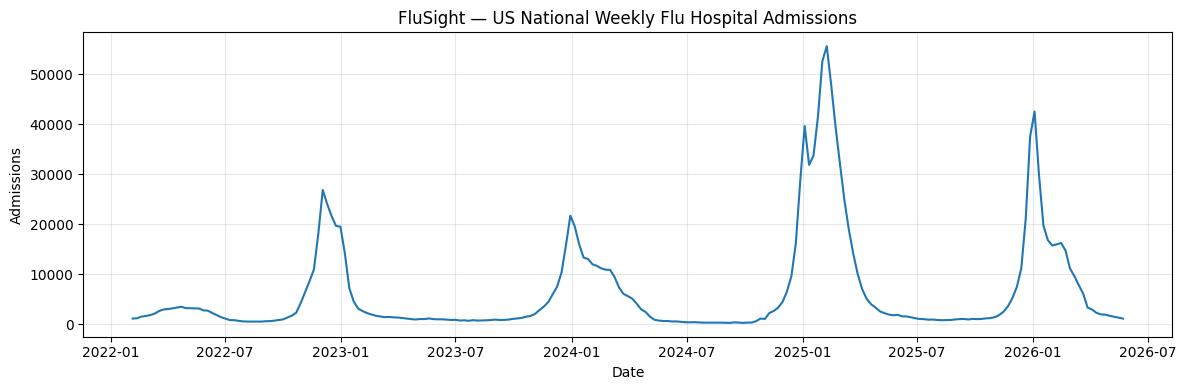

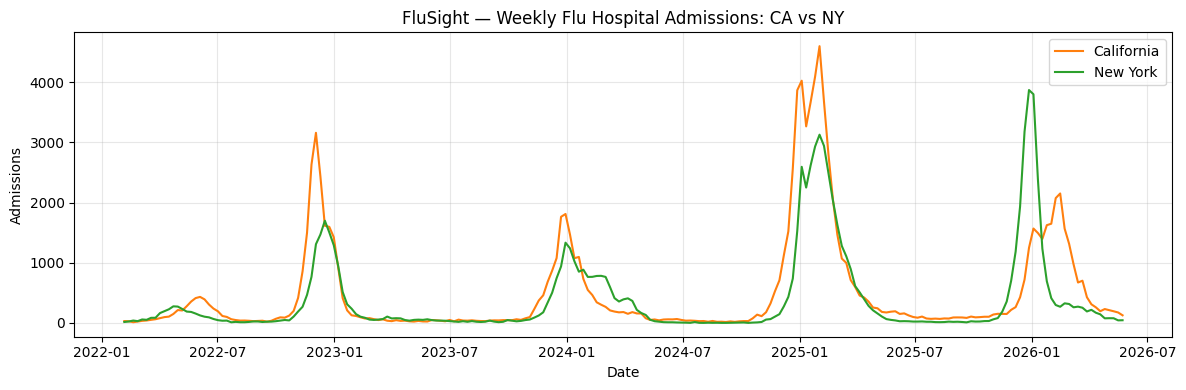

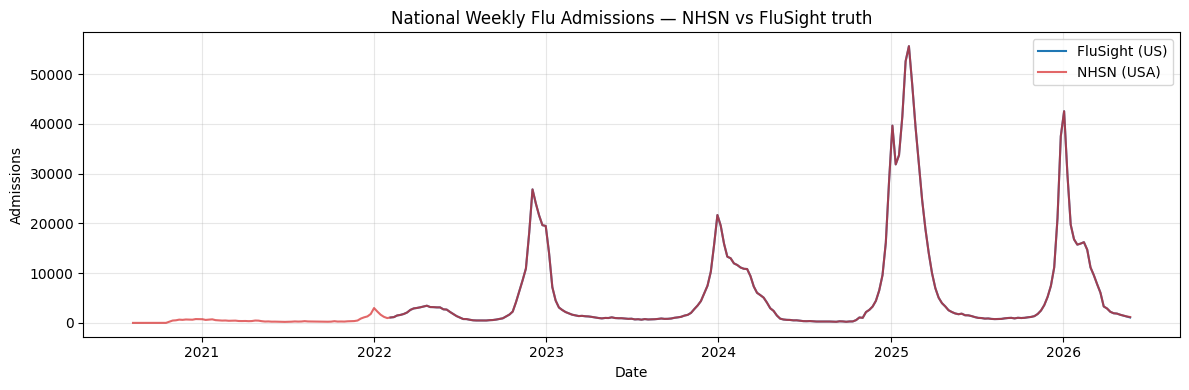

Figures saved to C:\Users\UseR\Downloads\Epidemic Forecasting\data\processed\figures


In [7]:
def series(df, loc):
    s = df[df["location"] == loc].sort_values("date")
    return s["date"], s["value"]

# 7a — US national hospitalizations (FluSight)
fig, ax = plt.subplots(figsize=(12, 4))
x, y = series(flusight, "US")
ax.plot(x, y, color="tab:blue")
ax.set(title="FluSight — US National Weekly Flu Hospital Admissions",
       xlabel="Date", ylabel="Admissions")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, "us_national_hosp.png"), dpi=110)
plt.show()

# 7b — Example states: California & New York (FluSight)
fig, ax = plt.subplots(figsize=(12, 4))
for loc, lab, c in [("06", "California", "tab:orange"), ("36", "New York", "tab:green")]:
    x, y = series(flusight, loc)
    ax.plot(x, y, label=lab, color=c)
ax.set(title="FluSight — Weekly Flu Hospital Admissions: CA vs NY",
       xlabel="Date", ylabel="Admissions")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, "state_hosp_ca_ny.png"), dpi=110)
plt.show()

# 7c — NHSN vs FluSight (national). NHSN national label is 'USA'.
nat_label = "USA" if "USA" in set(nhsn["location"]) else nhsn["location"].mode().iloc[0]
fig, ax = plt.subplots(figsize=(12, 4))
x, y = series(flusight, "US");        ax.plot(x, y, label="FluSight (US)", color="tab:blue")
x, y = series(nhsn, nat_label);       ax.plot(x, y, label=f"NHSN ({nat_label})",
                                              color="tab:red", alpha=0.7)
ax.set(title="National Weekly Flu Admissions — NHSN vs FluSight truth",
       xlabel="Date", ylabel="Admissions")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, "nhsn_vs_flusight_national.png"), dpi=110)
plt.show()

print("Figures saved to", FIGS)

## Cell 8 — Data quality & coverage summary (computed)

In [8]:
def coverage(df, name, loc_col="location"):
    return {"dataset": name, "rows": len(df),
            "locations": df[loc_col].nunique(),
            "start": df["date"].min().date(), "end": df["date"].max().date()}

summary = pd.DataFrame([
    coverage(flusight, "FluSight truth"),
    coverage(nhsn, "NHSN HRD"),
    coverage(ilinet, "ILINet"),
])
print(summary.to_string(index=False))

print("\nNHSN national label used:", nat_label)
print("Overlap window (NHSN vs FluSight):",
      max(nhsn['date'].min(), flusight['date'].min()).date(), "->",
      min(nhsn['date'].max(), flusight['date'].max()).date())

       dataset  rows  locations      start        end
FluSight truth 11889         53 2022-02-05 2026-05-23
      NHSN HRD 19430         67 2020-08-08 2026-05-23
        ILINet 40360         52 1997-09-28 2025-09-21

NHSN national label used: USA
Overlap window (NHSN vs FluSight): 2022-02-05 -> 2026-05-23


## Summary — what we learned

### What each dataset contains
- **FluSight ground truth** (`target-hospital-admissions.csv`) — weekly **incident confirmed-flu
  hospital admissions** per location. Locations use **2-digit FIPS** codes (`US` for national,
  `06`=CA, `36`=NY), 53 locations, plus a `weekly_rate` (per-100k). **This is the true
  forecasting target.**
- **NHSN HRD** — the CDC source the FluSight target is *derived from*: weekly confirmed-flu new
  admissions (`totalconfflunewadm`) by **jurisdiction** (2-letter state abbreviations, `USA`
  national). 322 columns total covering COVID/flu/RSV admissions, beds, and ICU; we keep only
  the flu-admissions slice.
- **ILINet** (Delphi `fluview`) — weekly **% of outpatient visits for influenza-like illness**.
  `ili` = unweighted (state-comparable), `wili` = weighted (national/HHS). A *syndromic*
  signal, **not** a hospitalization count — useful as a leading indicator, not a target.

### Which is the true target
**FluSight `target-hospital-admissions` (weekly flu hospital admissions).** NHSN is its upstream
raw source; ILINet is a correlated but different (outpatient ILI %) signal.

### Inconsistencies & data-quality notes
- **Spec filename outdated:** `truth-Incident Hospitalizations.csv` no longer exists; replaced by
  `target-hospital-admissions.csv` (saved locally as `flusight_truth.csv`).
- **Different units:** FluSight & NHSN are counts; ILINet is a percentage — not directly comparable.
- **Different location coding:** FIPS (FluSight) vs 2-letter abbrev (NHSN/ILINet) vs `nat`/`US`/`USA`
  national labels — a crosswalk is required to join them (see Cell 1).
- **Missing values:** reported per dataset in Cell 5 (NHSN has reporting gaps, esp. early weeks and
  small jurisdictions; ILINet `ili` is missing for some state/week combinations).
- **Reporting changes:** NHSN reporting was voluntary then mandatory (Nov 2024), creating level
  shifts; FluSight/NHSN admissions may diverge slightly due to revisions and inclusion rules.

### Time-coverage differences
- **ILINet:** longest history — weekly back to ~1997.
- **NHSN HRD:** ~2020 onward (pandemic-era reporting).
- **FluSight truth:** recent hub seasons (~2022 onward).
See the computed `summary` table and overlap window in Cell 8 for exact dates from this run.

> **Scope reminder:** No models, features, or future-filtering were built — Step 0 is data
> understanding only.